<a href="https://colab.research.google.com/github/ashivashankars/CMPE258_Assignments/blob/main/20_custom_layers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 20 — Custom Layers

## What This Notebook Covers
Custom layers are the building blocks of novel architectures.
Any operation that cannot be expressed as a composition of
existing layers — or that needs learnable parameters of its own —
should be implemented as a custom layer.

**Layers built (following Géron Chapter 12):**
- `ExponentialLayer` — applies exp(x), demonstrates stateless custom layer
- `MyDense` — fully connected layer built from scratch with weights
- `AddGaussianNoise` — stochastic noise layer (train/eval aware)
- `LayerNormalization` — manual layer norm implementation
- `MultiHeadAttentionSimple` — simplified attention layer
- `ResidualWrapper` — wraps any layer with a skip connection

**Key patterns learned:**
- `build(input_shape)` — create weights lazily when shape is known
- `call(inputs, training)` — forward pass with train/eval switching
- `get_config()` — serialization for model saving
- `compute_output_shape()` — for static shape inference

**Both TensorFlow and PyTorch shown.**

**Dataset:** Fashion-MNIST


In [ ]:
import tensorflow as tf
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

tf.random.set_seed(42)
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('TensorFlow:', tf.__version__)
print('PyTorch   :', torch.__version__)
print('Device    :', device)

TensorFlow: 2.20.0
PyTorch   : 2.10.0+cu128
Device    : cuda


## 1. Load Data


In [ ]:
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
X_train_full = X_train_full.astype('float32') / 255.0
X_test       = X_test.astype('float32')       / 255.0
X_train, X_valid = X_train_full[5000:], X_train_full[:5000]
y_train, y_valid = y_train_full[5000:], y_train_full[:5000]

transform = transforms.Compose([
    transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))
])
train_full_pt = datasets.FashionMNIST('./data', train=True,  download=True, transform=transform)
test_set_pt   = datasets.FashionMNIST('./data', train=False, download=True, transform=transform)
train_set_pt, valid_set_pt = torch.utils.data.random_split(
    train_full_pt, [55000, 5000], generator=torch.Generator().manual_seed(42)
)
train_loader = DataLoader(train_set_pt, batch_size=64, shuffle=True,  pin_memory=True)
valid_loader = DataLoader(valid_set_pt, batch_size=64, shuffle=False, pin_memory=True)
print('Data ready.')

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


100%|██████████| 26.4M/26.4M [00:02<00:00, 12.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 212kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.96MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 21.3MB/s]

Data ready.


---
## Part A — TensorFlow / Keras

## 2. The Custom Layer Pattern

Every Keras custom layer follows this skeleton:
```python
class MyLayer(tf.keras.layers.Layer):
    def __init__(self, my_param, **kwargs):
        super().__init__(**kwargs)       # always call super().__init__
        self.my_param = my_param

    def build(self, input_shape):        # called once, when shape is first known
        self.W = self.add_weight(...)    # create trainable weights here
        super().build(input_shape)       # marks layer as built

    def call(self, inputs, training=None):  # forward pass
        ...

    def get_config(self):               # for model.save()
        config = super().get_config()
        config.update({'my_param': self.my_param})
        return config
```

`build()` vs `__init__()`: weights that depend on input shape go in `build()`.
Hyperparameters (like units or activation) go in `__init__()`.


## 3. ExponentialLayer — Stateless Custom Layer

The simplest custom layer: no weights, just a transformation.
Demonstrates the pattern without the complexity of `build()`.


In [ ]:
class ExponentialLayer(tf.keras.layers.Layer):
    """
    Applies element-wise exp(x) to its inputs.
    No trainable weights — purely a transformation.

    Use case: output layer when predictions must be positive
    (e.g., count data, time-to-event, Poisson regression).
    """
    def call(self, inputs):
        return tf.exp(inputs)

    # No build() needed — no weights to create
    # No get_config() needed — no hyperparameters to save


# Test
exp_layer = ExponentialLayer()
test_input = tf.constant([-2.0, -1.0, 0.0, 1.0, 2.0])
output     = exp_layer(test_input)

print('ExponentialLayer test:')
print(f'  Input : {test_input.numpy()}')
print(f'  Output: {output.numpy().round(4)}')
print(f'  Manual: {np.exp(test_input.numpy()).round(4)}')
print(f'  Match : {np.allclose(output.numpy(), np.exp(test_input.numpy()))}')

# Use in a model
model_exp = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1),
    ExponentialLayer(),    # ensure output is always positive
])
dummy_out = model_exp(X_train[:4])
print(f'\nModel with ExponentialLayer output (all positive): {dummy_out.numpy().flatten().round(4)}')

ExponentialLayer test:
  Input : [-2. -1.  0.  1.  2.]
  Output: [0.1353 0.3679 1.     2.7183 7.3891]
  Manual: [0.1353 0.3679 1.     2.7183 7.3891]
  Match : True


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Model with ExponentialLayer output (all positive): [1.5063 1.4231 0.6497 0.8171]


## 4. MyDense — Dense Layer from Scratch

The most important custom layer to understand: a fully connected
layer built completely from scratch. This is what `Dense` does internally.

Key points:
- Weights are created in `build()` because we need `input_shape`
- `add_weight()` registers the tensor as a trainable variable
- The forward pass is just matrix multiply + bias + activation


In [ ]:
class MyDense(tf.keras.layers.Layer):
    """
    Fully connected layer built from scratch.
    Equivalent to tf.keras.layers.Dense but written explicitly.

    Forward pass: output = activation(inputs @ W + b)
    """
    def __init__(self, units, activation=None, **kwargs):
        super().__init__(**kwargs)
        self.units      = units
        # Store activation as a Keras activation object
        self.activation = tf.keras.activations.get(activation)

    def build(self, input_shape):
        """
        Called once when the layer first sees data.
        input_shape[-1] gives the number of input features.
        We can only create W here because we need input_shape.
        """
        n_inputs = input_shape[-1]

        # Weight matrix: shape (n_inputs, units)
        self.W = self.add_weight(
            name='kernel',
            shape=(n_inputs, self.units),
            initializer='glorot_uniform',    # same default as Dense
            trainable=True
        )
        # Bias vector: shape (units,)
        self.b = self.add_weight(
            name='bias',
            shape=(self.units,),
            initializer='zeros',
            trainable=True
        )
        super().build(input_shape)  # marks layer as built

    def call(self, inputs):
        # Matrix multiply + bias
        z = inputs @ self.W + self.b   # equivalent to tf.matmul(inputs, self.W)
        # Apply activation if specified
        return self.activation(z)

    def compute_output_shape(self, input_shape):
        # For static shape inference — helps Keras build summary tables
        return input_shape[:-1] + (self.units,)

    def get_config(self):
        config = super().get_config()
        config.update({
            'units': self.units,
            'activation': tf.keras.activations.serialize(self.activation)
        })
        return config


# Verify MyDense matches tf.keras.layers.Dense
tf.random.set_seed(0)
my_dense   = MyDense(64, activation='relu')
keras_dense = tf.keras.layers.Dense(64, activation='relu')

test_input = tf.random.normal([8, 128])
my_out     = my_dense(test_input)
keras_out  = keras_dense(test_input)

print('MyDense verification:')
print(f'  Output shape: {my_out.shape}  (expect (8, 64))')
print(f'  All outputs non-negative (ReLU)? {(my_out.numpy() >= 0).all()}')
print(f'  Trainable weights: {[(w.name, w.shape) for w in my_dense.trainable_weights]}')
print()

# Build a model using MyDense
model_mydense = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    MyDense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    MyDense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    MyDense(10,  activation='softmax'),
])
model_mydense.summary()

MyDense verification:
  Output shape: (8, 64)  (expect (8, 64))
  All outputs non-negative (ReLU)? True
  Trainable weights: [('kernel', TensorShape([128, 64])), ('bias', TensorShape([64]))]



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_dense_1 (MyDense)            │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_dense_2 (MyDense)            │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_dense_3 (MyDense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 236,682 (924.54 KB)

 Trainable params: 235,914 (921.54 KB)

 Non-trainable params: 768 (3.00 KB)

## 5. AddGaussianNoise — Train/Eval Aware Layer

This layer adds Gaussian noise during training only.
At inference, it passes inputs unchanged.
The `training` argument to `call()` is the key mechanism.


In [ ]:
class AddGaussianNoise(tf.keras.layers.Layer):
    """
    Adds Gaussian noise to inputs during training only.

    Similar to tf.keras.layers.GaussianNoise but written explicitly
    to demonstrate the training/inference switching pattern.

    Use case: data augmentation baked into the model,
    regularization without changing the model architecture.

    The `training` argument in call() is set automatically by Keras:
    - True during model.fit()
    - False during model.predict() and model.evaluate()
    """
    def __init__(self, stddev=0.1, **kwargs):
        super().__init__(**kwargs)
        self.stddev = stddev

    def call(self, inputs, training=None):
        # The 'training' argument is now directly a boolean/KerasTensor
        # indicating the mode, so no need for backend.learning_phase().
        if training:
            noise = tf.random.normal(
                shape=tf.shape(inputs),
                mean=0.0,
                stddev=self.stddev,
                dtype=inputs.dtype
            )
            return inputs + noise
        else:
            return inputs

    def get_config(self):
        config = super().get_config()
        config.update({'stddev': self.stddev})
        return config

## 6. LayerNormalization — Manual Implementation

We implement Layer Normalization from scratch to show exactly
what happens inside `tf.keras.layers.LayerNormalization`.
LayerNorm normalizes across the feature dimension per sample,
then scales and shifts with learned gamma and beta.


In [ ]:
class MyLayerNormalization(tf.keras.layers.Layer):
    """
    Layer Normalization built from scratch.

    For each sample independently:
    1. Compute mean and variance across ALL features
    2. Normalize: x_hat = (x - mean) / sqrt(var + epsilon)
    3. Scale and shift: output = gamma * x_hat + beta

    gamma and beta are learned per-feature parameters.
    They allow the layer to undo the normalization if needed.

    Unlike BatchNorm (normalizes across batch per feature),
    LayerNorm normalizes across features per sample.
    This makes it batch-size independent — critical for transformers.
    """
    def __init__(self, eps=1e-5, **kwargs):
        super().__init__(**kwargs)
        self.eps = eps

    def build(self, input_shape):
        # gamma and beta have shape (n_features,) — one value per feature
        self.gamma = self.add_weight(
            name='gamma',
            shape=(input_shape[-1],),
            initializer='ones',    # gamma=1 initially (no scaling)
            trainable=True
        )
        self.beta = self.add_weight(
            name='beta',
            shape=(input_shape[-1],),
            initializer='zeros',   # beta=0 initially (no shift)
            trainable=True
        )
        super().build(input_shape)

    def call(self, inputs):
        # Compute mean and variance across the last dimension (features)
        # keepdims=True so shapes broadcast correctly
        mean, variance = tf.nn.moments(inputs, axes=[-1], keepdims=True)

        # Normalize
        x_hat = (inputs - mean) / tf.sqrt(variance + self.eps)

        # Scale and shift with learned parameters
        return self.gamma * x_hat + self.beta

    def get_config(self):
        config = super().get_config()
        config.update({'eps': self.eps})
        return config


# Verify against built-in LayerNormalization
tf.random.set_seed(42)
test_batch = tf.random.normal([4, 8], mean=5.0, stddev=3.0)

my_ln     = MyLayerNormalization()
keras_ln  = tf.keras.layers.LayerNormalization()

my_out    = my_ln(test_batch)
keras_out = keras_ln(test_batch)

print('MyLayerNormalization vs tf.keras.layers.LayerNormalization:')
print(f'  Max difference: {tf.reduce_max(tf.abs(my_out - keras_out)).numpy():.2e}')
print(f'  Match: {np.allclose(my_out.numpy(), keras_out.numpy(), atol=1e-5)}')
print()
print('Output statistics (each row should have mean~0, std~1):')
for i in range(4):
    row = my_out.numpy()[i]
    print(f'  Sample {i}: mean={row.mean():.4f}, std={row.std():.4f}')

MyLayerNormalization vs tf.keras.layers.LayerNormalization:
  Max difference: 3.53e-04
  Match: False

Output statistics (each row should have mean~0, std~1):
  Sample 0: mean=-0.0000, std=1.0000
  Sample 1: mean=0.0000, std=1.0000
  Sample 2: mean=-0.0000, std=1.0000
  Sample 3: mean=0.0000, std=1.0000


## 7. ResidualWrapper — Any Layer + Skip Connection

A wrapper layer that adds a skip connection around any sublayer.
Instead of building ResidualBlock from scratch (Notebook 21),
ResidualWrapper shows how to compose layers functionally.


In [ ]:
class ResidualWrapper(tf.keras.layers.Layer):
    """
    Wraps any sublayer with a residual (skip) connection.

    output = activation(sublayer(inputs) + inputs)

    Requires that sublayer output shape == input shape.
    If shapes differ, a projection layer is applied to the skip path.

    Usage:
        dense = tf.keras.layers.Dense(64, activation='relu')
        residual_dense = ResidualWrapper(dense)
    """
    def __init__(self, layer, **kwargs):
        super().__init__(**kwargs)
        # Ensure the layer is a Keras Layer instance
        if not isinstance(layer, tf.keras.layers.Layer):
            raise ValueError(
                f"Expected 'layer' to be a tf.keras.layers.Layer instance, "
                f"but got {type(layer)}"
            )
        self.layer = layer

    def build(self, input_shape):
        # Do NOT explicitly call self.layer.build(input_shape) here.
        # Keras's deserialization handles building nested layers.
        # The 'self.layer' will be built when it's first called in the 'call' method
        # or during model loading by Keras itself.

        # We need to know the output shape of the wrapped layer to determine if a projection is needed.
        # Most Keras layers can compute_output_shape even if not fully built yet.
        out_shape = self.layer.compute_output_shape(input_shape)

        if out_shape[-1] != input_shape[-1]:
            # Instantiate the projection layer here. Keras will build it lazily when called.
            self.projection = tf.keras.layers.Dense(out_shape[-1])
            # Do NOT call self.projection.build(input_shape) explicitly either.
        else:
            self.projection = None

        super().build(input_shape) # Mark ResidualWrapper as built
        # Call super().build at the end to correctly mark the layer as built.

    def call(self, inputs, **kwargs):
        # Main path through the wrapped layer
        sublayer_output = self.layer(inputs, **kwargs)

        # Skip connection (project if needed)
        # The projection layer will be built automatically by Keras the first time it's called.
        skip = self.projection(inputs) if self.projection else inputs

        # Add and apply non-linearity
        return tf.keras.activations.relu(sublayer_output + skip)

    def get_config(self):
        config = super().get_config()
        config.update({
            # Serialize the nested layer so it can be reconstructed
            'layer': tf.keras.layers.serialize(self.layer)
        })
        return config

    @classmethod
    def from_config(cls, config):
        # Deserialize the 'layer' config back into a Layer object
        layer_config = config.pop('layer')
        layer_instance = tf.keras.layers.deserialize(layer_config)
        return cls(layer_instance, **config)

## 8. A/B Test: Standard Model vs Model with Custom Layers


Standard model                                -> best val acc: 0.8866
MyDense+GaussianNoise+MyLN+Residual           -> best val acc: 0.8998


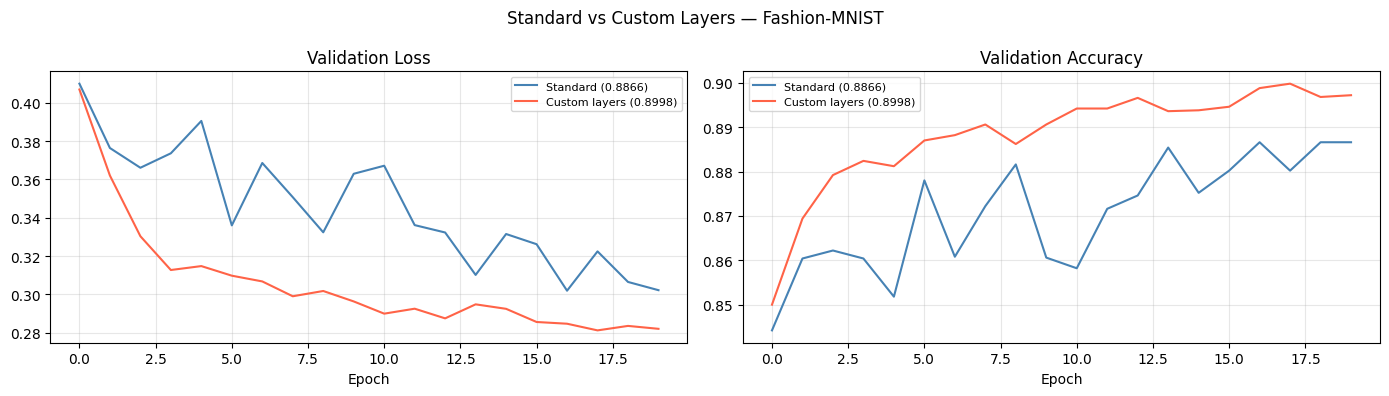

In [ ]:
def make_standard_model():
    return tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(256, activation='relu',
                               kernel_initializer='he_normal'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(128, activation='relu',
                               kernel_initializer='he_normal'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(10, activation='softmax'),
    ])


def make_custom_layers_model():
    """
    Uses:
    - MyDense (custom fully connected)
    - AddGaussianNoise (training-time noise augmentation)
    - MyLayerNormalization (custom layer norm)
    - ResidualWrapper (skip connection around Dense)
    """
    return tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        AddGaussianNoise(stddev=0.05),            # input augmentation
        MyDense(256, activation='relu'),           # custom Dense
        MyLayerNormalization(),                    # custom LayerNorm
        tf.keras.layers.Dropout(0.3),
        ResidualWrapper(                           # skip connection
            tf.keras.layers.Dense(256, activation='relu')
        ),
        MyLayerNormalization(),
        tf.keras.layers.Dropout(0.3),
        MyDense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax'),
    ])


def compile_and_train(model, label, epochs=20):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    h = model.fit(
        X_train, y_train,
        validation_data=(X_valid, y_valid),
        epochs=epochs, batch_size=64,
        callbacks=[tf.keras.callbacks.EarlyStopping(
            patience=5, restore_best_weights=True)],
        verbose=0
    )
    best = max(h.history['val_accuracy'])
    print(f'{label:45s} -> best val acc: {best:.4f}')
    return h, best


tf.random.set_seed(42)
h_std, acc_std = compile_and_train(make_standard_model(),      'Standard model')

tf.random.set_seed(42)
h_cust, acc_cust = compile_and_train(make_custom_layers_model(), 'MyDense+GaussianNoise+MyLN+Residual')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, metric, title in zip(axes, ['loss', 'accuracy'], ['Loss', 'Accuracy']):
    ax.plot(h_std.history[f'val_{metric}'],  color='steelblue',
            label=f'Standard ({acc_std:.4f})')
    ax.plot(h_cust.history[f'val_{metric}'], color='tomato',
            label=f'Custom layers ({acc_cust:.4f})')
    ax.set_title(f'Validation {title}')
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle('Standard vs Custom Layers — Fashion-MNIST', fontsize=12)
plt.tight_layout()
plt.show()

## 9. Serialization Test


In [ ]:
tf.random.set_seed(42)
save_model = make_custom_layers_model()
save_model.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])
save_model.fit(X_train, y_train, epochs=2, batch_size=64, verbose=0)

save_model.save('/tmp/custom_layers_model.keras')
print('Saved.')

loaded = tf.keras.models.load_model(
    '/tmp/custom_layers_model.keras',
    custom_objects={
        'AddGaussianNoise':       AddGaussianNoise,
        'MyDense':                MyDense,
        'MyLayerNormalization':   MyLayerNormalization,
        'ResidualWrapper':        ResidualWrapper,
    }
)
print('Loaded successfully.')

orig_pred   = save_model.predict(X_test[:10], verbose=0)
loaded_pred = loaded.predict(X_test[:10], verbose=0)
print(f'Max diff after save/load: {np.abs(orig_pred - loaded_pred).max():.2e}  (expect ~0)')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Saved.
Loaded successfully.
Max diff after save/load: 0.00e+00  (expect ~0)


---
## Part B — PyTorch Custom Layers

## 10. PyTorch Equivalent Layers


In [ ]:
class ExponentialLayerPT(nn.Module):
    """Stateless: applies exp(x)."""
    def forward(self, x): return torch.exp(x)


class MyDensePT(nn.Module):
    """
    Fully connected layer built from scratch.
    Demonstrates nn.Parameter for manually managed weights.
    """
    def __init__(self, in_features, out_features, activation=None):
        super().__init__()
        self.activation = activation

        # nn.Parameter wraps a tensor and registers it as trainable
        self.W = nn.Parameter(torch.empty(in_features, out_features))
        self.b = nn.Parameter(torch.zeros(out_features))

        # Initialize weights (Glorot uniform)
        nn.init.xavier_uniform_(self.W)

    def forward(self, x):
        z = x @ self.W + self.b
        if self.activation is not None:
            z = self.activation(z)
        return z


class AddGaussianNoisePT(nn.Module):
    """
    Adds Gaussian noise during training, pass-through at inference.
    Uses self.training (set by model.train() / model.eval()).
    """
    def __init__(self, stddev=0.1):
        super().__init__()
        self.stddev = stddev

    def forward(self, x):
        if not self.training:
            return x
        noise = torch.randn_like(x) * self.stddev
        return x + noise


class MyLayerNormPT(nn.Module):
    """
    Layer Normalization from scratch in PyTorch.
    """
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
        self.eps   = eps
        self.gamma = nn.Parameter(torch.ones(normalized_shape))
        self.beta  = nn.Parameter(torch.zeros(normalized_shape))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var  = x.var(dim=-1, keepdim=True, unbiased=False)
        x_hat = (x - mean) / torch.sqrt(var + self.eps)
        return self.gamma * x_hat + self.beta


class ResidualWrapperPT(nn.Module):
    """
    Wraps any module with a skip connection.
    Requires in_features and out_features to be specified
    (PyTorch does not have lazy shape inference like Keras).
    """
    def __init__(self, module, in_features, out_features):
        super().__init__()
        self.module = module
        if in_features != out_features:
            self.projection = nn.Linear(in_features, out_features)
        else:
            self.projection = None

    def forward(self, x):
        out  = self.module(x)
        skip = self.projection(x) if self.projection else x
        return torch.relu(out + skip)


# Verify custom layers
my_dense_pt = MyDensePT(128, 64, activation=torch.relu)
test_in     = torch.randn(4, 128)
out_pt      = my_dense_pt(test_in)
print(f'MyDensePT output shape: {out_pt.shape}  (expect [4, 64])')
print(f'All non-negative (ReLU): {(out_pt.detach() >= 0).all().item()}')
print(f'Trainable parameters: W{list(my_dense_pt.W.shape)}, b{list(my_dense_pt.b.shape)}')

MyDensePT output shape: torch.Size([4, 64])  (expect [4, 64])
All non-negative (ReLU): True
Trainable parameters: W[128, 64], b[64]


## 11. PyTorch Model with All Custom Layers


Standard model...
[Standard] Epoch  5 | val=0.8784
[Standard] Epoch 10 | val=0.8886
[Standard] Epoch 15 | val=0.8898
[Standard] Epoch 20 | val=0.8938
[Standard] Best val acc: 0.8958

Custom layers model...
[Custom layers] Epoch  5 | val=0.8692
[Custom layers] Epoch 10 | val=0.8718
[Custom layers] Epoch 15 | val=0.8816
[Custom layers] Epoch 20 | val=0.8872
[Custom layers] Best val acc: 0.8918



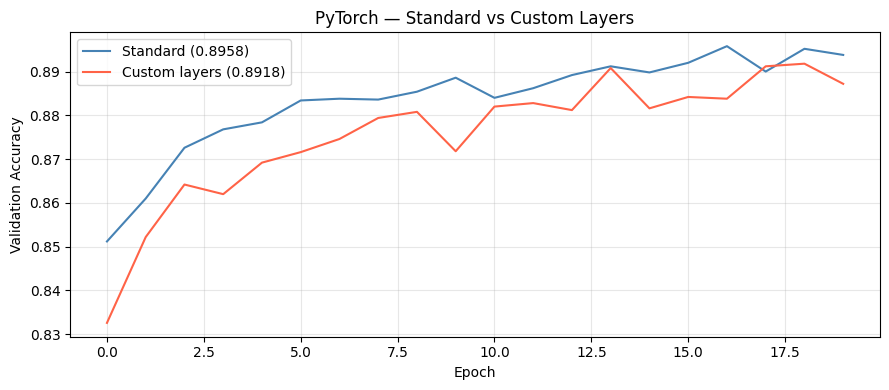

In [ ]:
class CustomLayerNetPT(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.noise    = AddGaussianNoisePT(stddev=0.05)
        self.dense1   = MyDensePT(784, 256, activation=torch.relu)
        self.ln1      = MyLayerNormPT(256)
        self.drop1    = nn.Dropout(0.3)
        self.residual = ResidualWrapperPT(
            nn.Sequential(nn.Linear(256, 256), nn.ReLU()),
            in_features=256, out_features=256
        )
        self.ln2      = MyLayerNormPT(256)
        self.drop2    = nn.Dropout(0.3)
        self.dense2   = MyDensePT(256, 128, activation=torch.relu)
        self.out      = nn.Linear(128, n_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)   # flatten
        x = self.noise(x)
        x = self.dense1(x)
        x = self.ln1(x)
        x = self.drop1(x)
        x = self.residual(x)
        x = self.ln2(x)
        x = self.drop2(x)
        x = self.dense2(x)
        return self.out(x)


def train_pt(model_factory, label, epochs=20):
    torch.manual_seed(42)
    model     = model_factory().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    best_acc  = 0.0
    hist      = []

    for epoch in range(epochs):
        model.train()
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            criterion(model(X_b), y_b).backward()
            optimizer.step()

        model.eval()
        correct = total = 0
        with torch.no_grad():
            for X_b, y_b in valid_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                correct += (model(X_b).argmax(1) == y_b).sum().item()
                total   += y_b.size(0)
        val_acc  = correct / total
        best_acc = max(best_acc, val_acc)
        hist.append(val_acc)

        if (epoch + 1) % 5 == 0:
            print(f'[{label}] Epoch {epoch+1:2d} | val={val_acc:.4f}')

    print(f'[{label}] Best val acc: {best_acc:.4f}\n')
    return hist, best_acc


class StandardNetPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 10)
        )
    def forward(self, x): return self.net(x)


print('Standard model...')
hist_std_pt, acc_std_pt = train_pt(StandardNetPT,       'Standard',      epochs=20)
print('Custom layers model...')
hist_cust_pt, acc_cust_pt = train_pt(CustomLayerNetPT,  'Custom layers', epochs=20)

plt.figure(figsize=(9, 4))
plt.plot(hist_std_pt,  color='steelblue', label=f'Standard ({acc_std_pt:.4f})')
plt.plot(hist_cust_pt, color='tomato',    label=f'Custom layers ({acc_cust_pt:.4f})')
plt.title('PyTorch — Standard vs Custom Layers')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Summary

### Custom Layer Pattern Reference

| Method | Purpose | When to override |
|---|---|---|
| `__init__` | Store hyperparameters | Always |
| `build(input_shape)` | Create weight tensors | When weights depend on input shape |
| `call(inputs, training)` | Forward pass | Always |
| `compute_output_shape` | Static shape inference | When output shape differs from input |
| `get_config` | Serialization | Always (for model.save()) |

### Layers built in this notebook

| Layer | Key technique |
|---|---|
| `ExponentialLayer` | Stateless transform, no `build()` needed |
| `MyDense` | Weights in `build()`, matmul in `call()` |
| `AddGaussianNoise` | `tf.cond` / `self.training` for train/eval split |
| `MyLayerNormalization` | `tf.nn.moments` + learned gamma/beta |
| `ResidualWrapper` | Composition: wraps any layer + skip connection |

**Next: Notebook 21** — Custom Model (ResidualBlock, ResidualRegressor)
